<a href="https://colab.research.google.com/github/besturkmen/AcademiQ_Data_Science/blob/main/AcademiQ_Data_Science_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

In [ ]:
wholesale_custumers = fetch_ucirepo(id=292)

X= wholesale_custumers.data.features.copy()

print("Dataset Boyutları:", X.shape)

display(X.head())

Dataset Boyutları: (440, 7)


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


In [ ]:


display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[ 1.44865163  0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873
  -0.06633906]
 [ 1.44865163 -0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684
   0.08915105]
 [ 1.44865163 -0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164
   2.24329255]
 [-0.69029709  0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822
   0.09341105]
 [ 1.44865163  0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782
   1.29934689]]


# Elbow Method



In [ ]:
inertia_values = []
cluster_range = range(1,11)

for k in cluster_range:
  model =KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10
  )
  model.fit(X_scaled)
  inertia_values.append(model.inertia_)


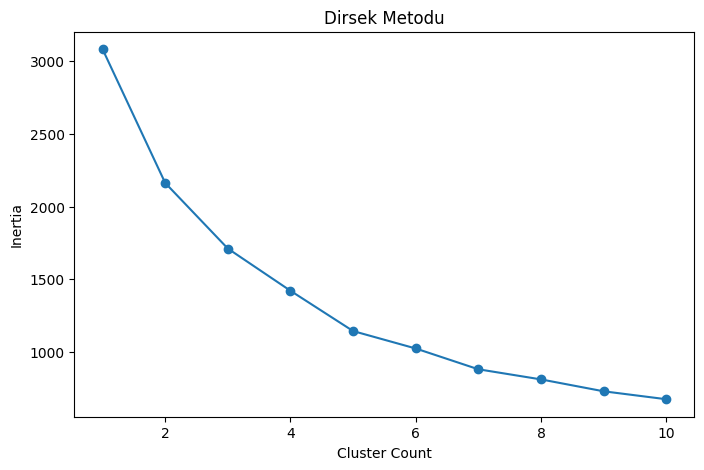

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    inertia_values,
    marker='o',

)
plt.title('Dirsek Metodu')
plt.xlabel('Cluster Count')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans_pipeline = Pipeline(steps = [
    (
        "kmeans",
        KMeans(
            n_clusters=4,
            random_state=42,
            n_init=10
        )
    )
])
kmeans_pipeline.fit(X_scaled)

Pipeline(steps=[('kmeans', KMeans(n_clusters=4, n_init=10, random_state=42))])

In [ ]:
clusters= kmeans_pipeline.predict(X_scaled)
X_clustered= X.copy()
X_clustered["cluster"]= clusters

display(X_clustered.head())

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,12669,9656,7561,214,2674,1338,0
1,2,7057,9810,9568,1762,3293,1776,0
2,2,6353,8808,7684,2405,3516,7844,0
3,1,13265,1196,4221,6404,507,1788,1
4,2,22615,5410,7198,3915,1777,5185,0


In [ ]:
score= silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(score,4))

Silhouette Score: 0.4425


Score

- 0.70+ ----------------- Çok güçlü ayrışma
- 0.50 - 0.70  ---------- Güçlü
- 0.25 - 0.50  ---------- Orta / Kabul edilebilir ayrışma
- < 0.25  --------------- Zayıf ayrışma